References:

Brownlee, J. (2016, July 21). Time series prediction with LSTM recurrent neural networks in Python with Keras. Machine Learning Mastery. Retrieved from https://www.machinelearningmastery.com/time-series-prediction-lstm-recurrent-neural-networks-python-keras/ 

Ujhelyi, T. (2021, November 16). Polynomial regression in Python using scikit-learn (with a practical example). Data36. Retrieved from https://data36.com/polynomial-regression-python-scikit-learn/

GeeksforGeeks. (2025, July 23). Implementing neural networks using TensorFlow. GeeksforGeeks. Retrieved from https://www.geeksforgeeks.org/deep-learning/implementing-neural-networks-using-tensorflow/

W3Schools.com. (n.d.). Python Machine Learning – K-means. Retrieved from https://www.w3schools.com/python/python_ml_k-means.asp

## Topic 1 (Andy)

### Task 0

In [14]:
from mw_plot import MWFaceOn
print("mw_plot works!")

mw_plot works!


### Task 1

Reproducing the image of milky way via MWSkyMap

In [1]:
from astropy.coordinates import SkyCoord
from astropy import units as u
from proj4functions import get_galactic_coords


print("M31 (l, b):", get_galactic_coords("M31"))
print("Polaris (l, b):", get_galactic_coords("Polaris"))
print("M13 (l, b):", get_galactic_coords("M13"))


M31 (l, b): (121.17432903730572, -21.573308797618147)
Polaris (l, b): (123.2805496667062, 26.461395977136508)
M13 (l, b): (59.00947454661739, 40.9117614396569)


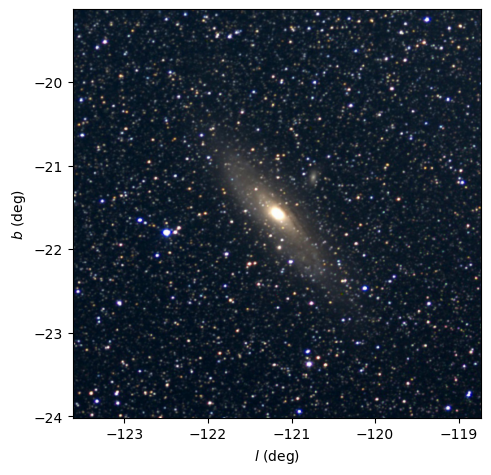

In [2]:
import matplotlib.pyplot as plt
from astropy import units as u
from mw_plot import MWSkyMap

# M31 in Galactic coordinates (l, b)
l_m31 = -121.17432 * u.deg
b_m31 = -21.57330 * u.deg

mw1 = MWSkyMap(
    center=(l_m31, b_m31),                 
    radius=(8800, 8800) * u.arcsec,
    background="Mellinger color optical survey",
)

fig, ax = plt.subplots(figsize=(5, 5))
mw1.transform(ax)

mw1.savefig("galaxy.png")  

Using the "M31" positions

### Task 2

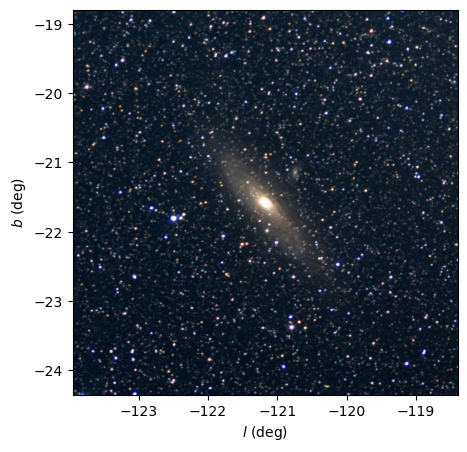

In [3]:
mwA = MWSkyMap(
    center=(l_m31, b_m31),
    radius=(10000, 10000) * u.arcsec,
    background="Mellinger color optical survey"
)
fig, ax = plt.subplots(figsize=(5, 5))
mwA.transform(ax)
plt.show()

using the center as "M31" with radius (10 000, 10 000)

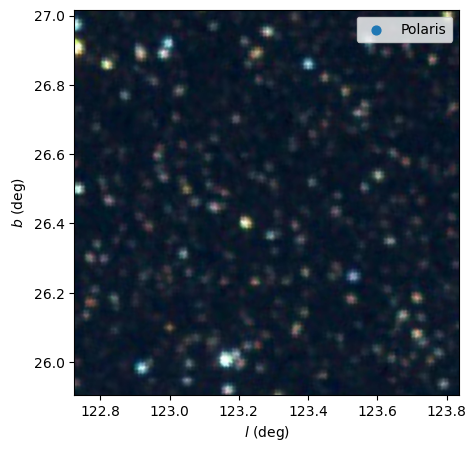

In [4]:
l_pol, b_pol = get_galactic_coords("Polaris")

mwB = MWSkyMap(
    center=(l_pol * u.deg, b_pol * u.deg),
    radius=(2000, 2000) * u.arcsec,
    background="Mellinger color optical survey"
)

fig, ax = plt.subplots(figsize=(5, 5))
mwB.transform(ax)

ax.scatter(l_pol, b_pol, s=40, label="Polaris")
ax.legend()

plt.show()


Changed the center into "Polaris" and using the radius (2000, 2000)

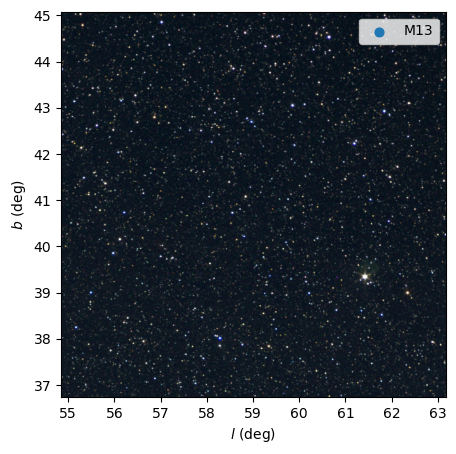

In [5]:
# Get galactic coordinates of M13
l_m13, b_m13 = get_galactic_coords("M13")

# Create sky map centered on M13
mw_m13 = MWSkyMap(
    center=(l_m13 * u.deg, b_m13 * u.deg),
    radius=(15000, 15000) * u.arcsec,     # you can change this if you want larger/smaller
    background="Mellinger color optical survey"
)

fig, ax = plt.subplots(figsize=(5, 5))
mw_m13.transform(ax)

ax.scatter(l_m13, b_m13, s=40, label="M13")

ax.legend()
plt.show()

Changed the center into "M13" and the radius into (15 000, 15 000)

### Task 3

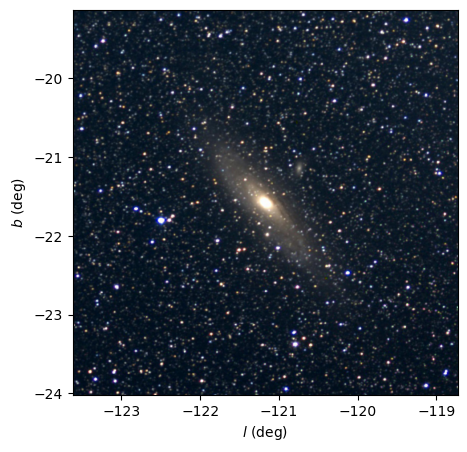

RGB array shape: (500, 500, 3)


In [7]:
import numpy as np

from proj4functions import plt2rgbarr

l_m31 = -121.17432 * u.deg
b_m31 = -21.57330 * u.deg

mw1 = MWSkyMap(
    center=(l_m31, b_m31),
    radius=(8800, 8800) * u.arcsec,
    background="Mellinger color optical survey"
)

fig, ax = plt.subplots(figsize=(5, 5))
mw1.transform(ax)
plt.show()


img_array = plt2rgbarr(fig)

print("RGB array shape:", img_array.shape)

RGB array shape: (500, 500, 3)

### Task 4 

I converted the RGB image to grayscale using a weighted sum, then i classify pixels into three categories:

bright stars: grayscale > 230
medium stars: grayscale between 180-230
background: grayscale <180


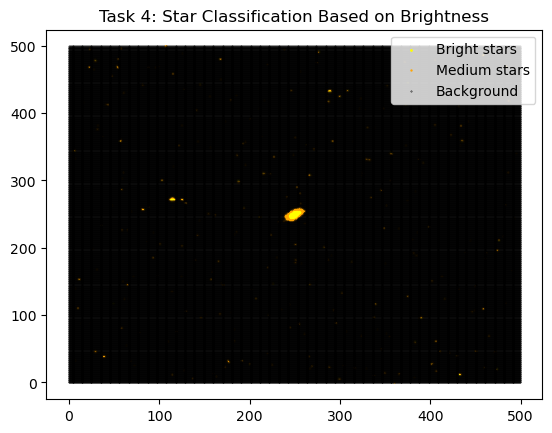

In [8]:
grey = np.sum(img_array[:, :, :3] * np.array([0.299, 0.587, 0.114]), axis=2)

bright = np.where(grey > 230)
medium = np.where((grey <= 230) & (grey > 180))
dark = np.where(grey <= 180)

plt.scatter(bright[1], bright[0], s=1, color="yellow", label="Bright stars")
plt.scatter(medium[1], medium[0], s=0.5, color="orange", label="Medium stars")
plt.scatter(dark[1], dark[0], s=0.1, color="black", label="Background")
plt.title("Task 4: Star Classification Based on Brightness")


plt.legend()
plt.show()


### Task 5

Number of bright pixels: 539


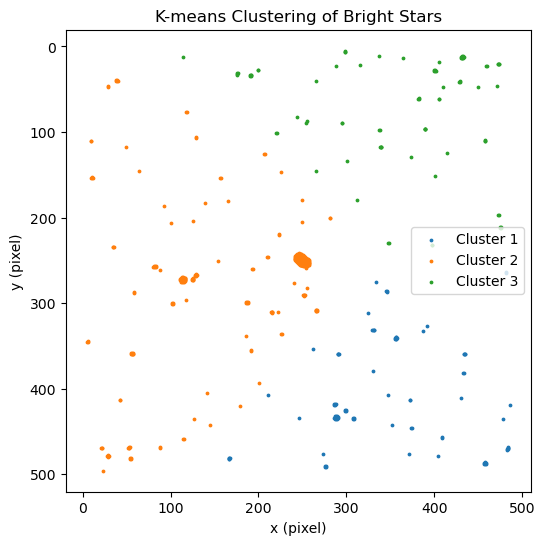

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


points = np.column_stack((bright[1], bright[0])) 
print("Number of bright pixels:", points.shape[0])

# k-means clustering, source: https://www.w3schools.com/python/python_ml_k-means.asp
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
labels = kmeans.fit_predict(points)

# plot cluster
plt.figure(figsize=(6, 6))
for i in range(3):
    cluster_points = points[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                s=3, label=f"Cluster {i+1}")

plt.gca().invert_yaxis()
plt.title("K-means Clustering of Bright Stars")
plt.xlabel("x (pixel)")
plt.ylabel("y (pixel)")
plt.legend()
plt.show()


### Task 6

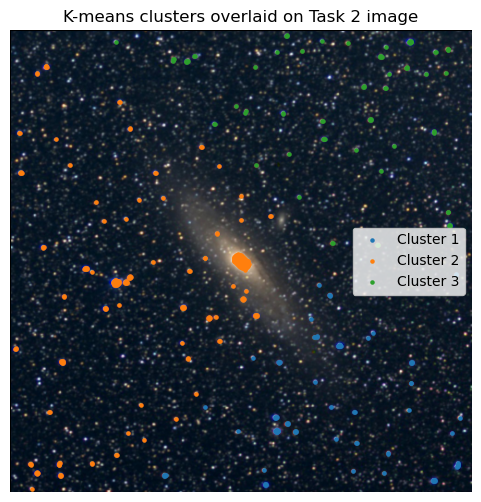

In [10]:


# img_array : from Task 3 (shape ~ (500, 500, 3))
# points    : from Task 5, np.column_stack((bright[1], bright[0]))
# labels    : from Task 5, kmeans.fit_predict(points)

plt.figure(figsize=(6, 6))

# Show the original galaxy image (Task 2 result)
plt.imshow(img_array)        
plt.axis('off')

# Over-impose the clusters
for i in range(3):  
    cluster_points = points[labels == i]
    plt.scatter(
        cluster_points[:, 0], 
        cluster_points[:, 1],  
        s=5,
        label=f"Cluster {i+1}"
    )

plt.title("K-means clusters overlaid on Task 2 image")
plt.legend()
plt.show()


### Task 7
Try different categories (task 4), repeating tasks 5 and 6, and provide an explanation of your results. What can we learn from an unsupervised model of our galaxy?


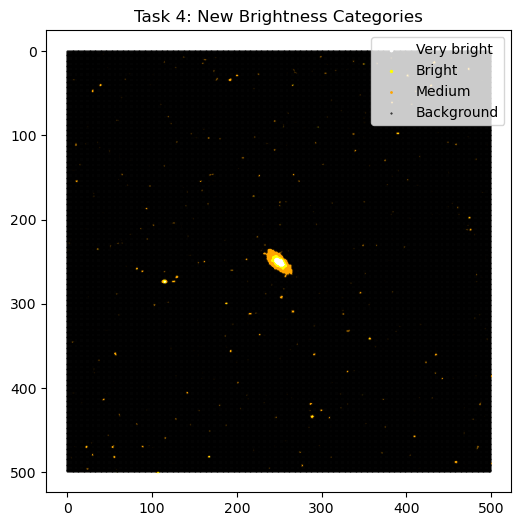

In [11]:
# Task 4 original

# Convert image to grayscale
grey = np.sum(img_array[:, :, :3] * np.array([0.299, 0.587, 0.114]), axis=2)

# new categories
very_bright = np.where(grey > 240)
bright      = np.where((grey <= 240) & (grey > 200))
medium      = np.where((grey <= 200) & (grey > 140))
dark        = np.where(grey <= 140)

plt.figure(figsize=(6, 6))
plt.gca().invert_yaxis()

plt.scatter(very_bright[1], very_bright[0], s=3, color="white",  label="Very bright")
plt.scatter(bright[1],      bright[0],      s=2, color="yellow", label="Bright")
plt.scatter(medium[1],      medium[0],      s=1, color="orange", label="Medium")
plt.scatter(dark[1],        dark[0],        s=0.2, color="black", label="Background")

plt.legend()
plt.title("Task 4: New Brightness Categories")
plt.show()

Number of bright pixels: 353


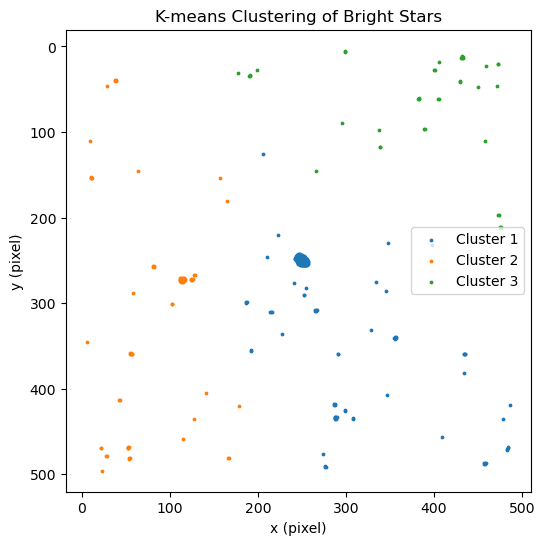

In [12]:
# Task 5 original
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

points = np.column_stack((very_bright[1], very_bright[0]))

print("Number of bright pixels:", points.shape[0])

# k-means clustering, sources: https://www.w3schools.com/python/python_ml_k-means.asp
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
labels = kmeans.fit_predict(points)

# plot cluster
plt.figure(figsize=(6, 6))
for i in range(3):
    cluster_points = points[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                s=3, label=f"Cluster {i+1}")

plt.gca().invert_yaxis()
plt.title("K-means Clustering of Bright Stars")
plt.xlabel("x (pixel)")
plt.ylabel("y (pixel)")
plt.legend()
plt.show()

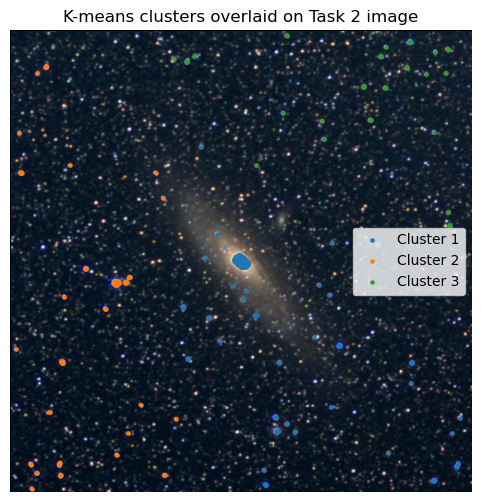

In [13]:
# Task 6 original

plt.figure(figsize=(6, 6))

# Show the original galaxy image (Task 2 result)
plt.imshow(img_array)          # image background
plt.axis('off')

# Over-impose the clusters
for i in range(3):  # same number of clusters as in Task 5
    cluster_points = points[labels == i]
    plt.scatter(
        cluster_points[:, 0],  # x (columns)
        cluster_points[:, 1],  # y (rows)
        s=5,
        label=f"Cluster {i+1}"
    )

plt.title("K-means clusters overlaid on Task 2 image")
plt.legend()
plt.show()


### Different categories, repeating task 5 & 6, and explanation of results

The goal in this task was to see how different brightness categories could affect the clustering results and what an unsupervised model can reveal about the structure of our galaxy.


The original task 4, i used 3 simple categories

- bright stars : grey > 230
- medium stars : 180 < grey <= 230
- background : grey <= 180

The new task 4 i changed was:

- adding very_bright : grey > 240
- bright stars: 200 < grey <= 240
- Medium stars: 140 < grey <= 200
- Background : grey <= 140

Created a more detailed separation between extremely bright pixels and normal bright stars.

Task 5 and 6 remained the same, the only line i changed in task 5 was just adding very_bright instead of bright:

- points = np.column_stack((very_bright[1], very_bright[0])) (new task 4)
  
- points = np.column_stack((bright[1], bright[0])) (original)

Result: 

In the original clustering, i used all bright stars (grey < 230), that included many smaller, weaker stars.

In the new clustering, i used very_bright + bright pixels (grey > 200), this removed many weak detections.

So the new cluster contains fewer points, but each of the point is more meaningful, representing strong, high-intensity object.

The new clusters align better with real structures in M31, the original clusters shows clusters scattered across the background stars and the new clustering creates a tighter, more concentrated groups.

The hole disappeard, in the old result you could see the brightest region of M31 appeard as a blue circle with a hole in the middle. This happens because the brightness threshold was to high (grey < 230), in the new encoding the threshold is a bit lower (grey > 0), the ring disappears, the cluster becomes a solid blob at the center.

What we can learn from an unsupervised model of our galaxy?

Using K-means on different brightness categories shows that an unsupervised model can discover real structure in astronomical images without any labels. When only the brightest pixels are used, the algorithm naturally identifies the galaxy’s central bulge as one cluster and separates the surrounding bright and medium-bright stars into others.

This means the model is able to detect meaningful patterns such as the concentration of light in the galactic core and the distribution of stars purely from pixel intensity. In other words, unsupervised learning helps reveal the underlying structure of the galaxy by grouping features that share similar brightness and spatial behavior.

## Topic 2 (Parsa)

### Task 0

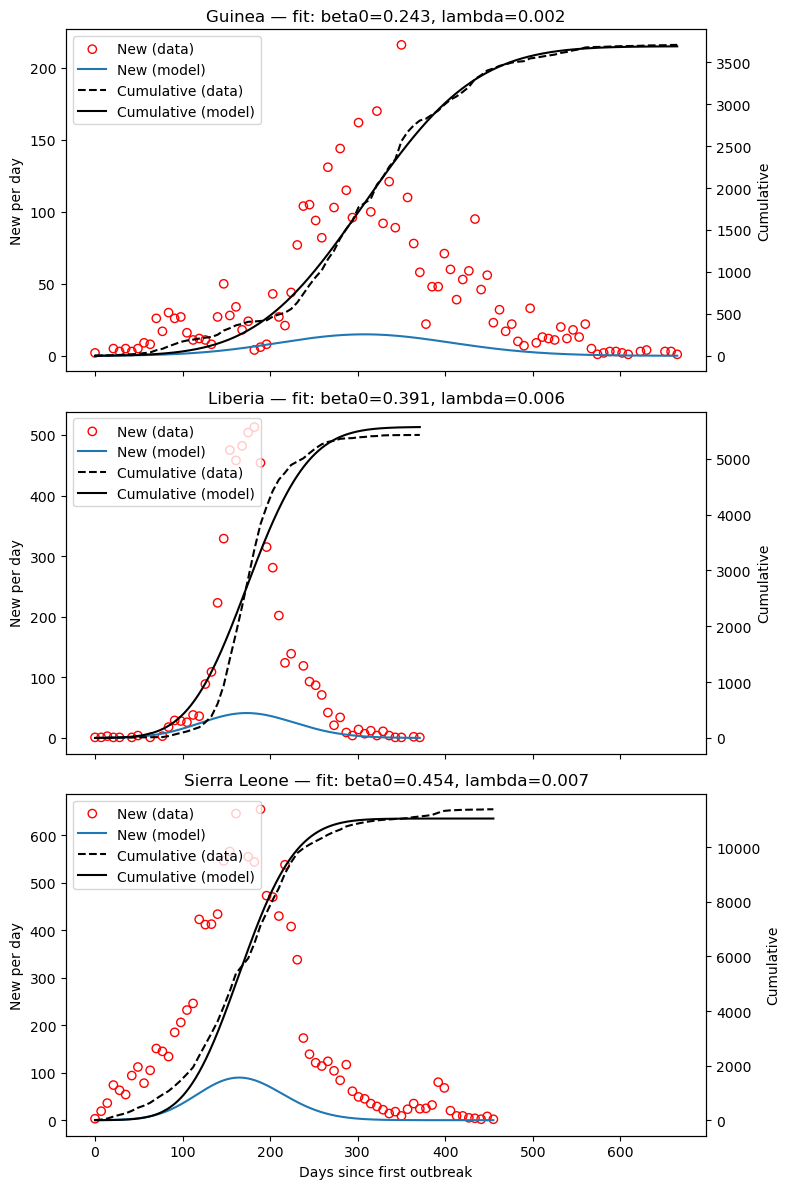

In [ ]:
# project 2 import

import numpy as np
import matplotlib.pyplot as plt
from proj4functions import load_country, fit_country



# File paths
countries = {
    "Guinea":       "ebola_cases_guinea.dat",
    "Liberia":      "ebola_cases_liberia.dat",
    "Sierra Leone": "ebola_cases_sierra_leone.dat",
}
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

for ax, (name, path) in zip(axes, countries.items()):
    days, new_data = load_country(path)
    (beta0_hat, lam_hat), (T, cum_model, new_model), cum_data, days0 = fit_country(days, new_data)

    # Left axis
    ax.scatter(days0, new_data, facecolors='none', edgecolors='red', label="New (data)")
    ax.plot(T, new_model, label="New (model)")
    ax.set_ylabel("New per day")

    # Right axis
    ax2 = ax.twinx()
    ax2.plot(days0, cum_data, "k--", label="Cumulative (data)")
    ax2.plot(T, cum_model, "k-", label="Cumulative (model)")
    ax2.set_ylabel("Cumulative")

    ax.set_title(f"{name} — fit: beta0={beta0_hat:.3f}, lambda={lam_hat:.3f}")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left")

axes[-1].set_xlabel("Days since first outbreak")
plt.tight_layout()
plt.show()


### Task 1
In Task 1 we used linear regression to fit a straight line to the cumulative Ebola cases vs. time for each country. The line clearly fails to capture the curved shape of the epidemic: it underestimates early growth and overestimates late values (or vice versa), showing that a simple linear trend is not appropriate for epidemic data

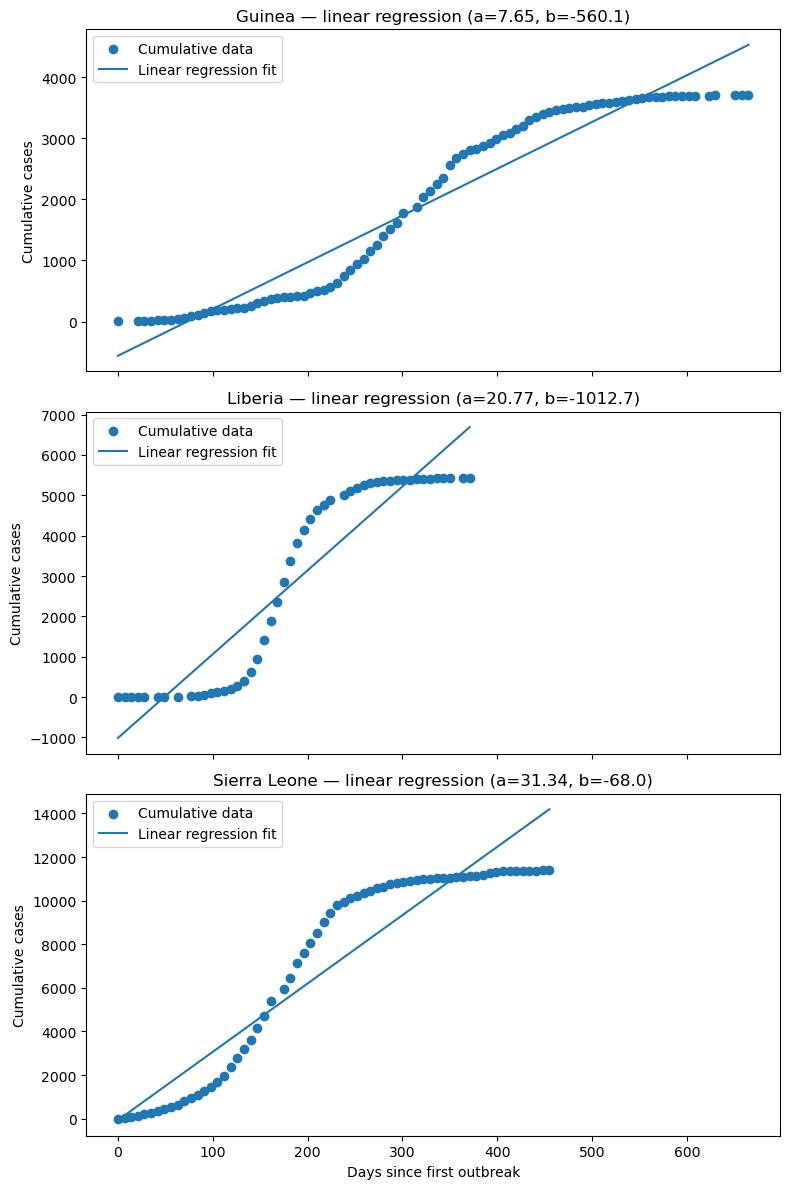

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from proj4functions import load_country

countries = {
    "Guinea": "ebola_cases_guinea.dat",
    "Liberia": "ebola_cases_liberia.dat",
    "Sierra Leone": "ebola_cases_sierra_leone.dat",
}

# Create one subplot per country
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

for ax, (name, path) in zip(axes, countries.items()):
    # Load data
    days, new_cases = load_country(path)
    days0 = days - days.min()
    cum_data = np.cumsum(new_cases)
    # Prepare data for linear regression
    X = days0.reshape(-1, 1)
    y = cum_data

    linreg = LinearRegression()
    linreg.fit(X, y)

    a = linreg.coef_[0]
    b = linreg.intercept_

    # Grid
    t_grid = np.linspace(days0.min(), days0.max(), 200).reshape(-1, 1)
    cum_pred = linreg.predict(t_grid)

    # Plot data 
    ax.scatter(days0, cum_data, label="Cumulative data")
    ax.plot(t_grid.ravel(), cum_pred, label="Linear regression fit")

    ax.set_title(f"{name} — linear regression (a={a:.2f}, b={b:.1f})")
    ax.set_ylabel("Cumulative cases")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Days since first outbreak")
plt.tight_layout()
plt.show()


The linear regression model has the form:  $$ C(t) = at + b $$
where t is the number of days since the first outbreak, and C(t) is the cumulative number of cases. The model was trained using scikit-learn’s LinearRegression on the data for each country.
The plots show that a straight-line model does not capture the epidemic dynamics well. Ebola outbreaks show nonlinear, accelerating growth followed by a slowdown, while a linear model assumes constant growth. As a result, the linear fit underestimates and overestimates large parts of the curve.

### Task 2

In this task I improved the linear regression model by adding polynomial features of the time variable. Instead of only using t, I created extra features like t^2 and t^3. Even though the model is still linear in its parameters, these extra features allow the curve to bend and fit the epidemic shape much better.

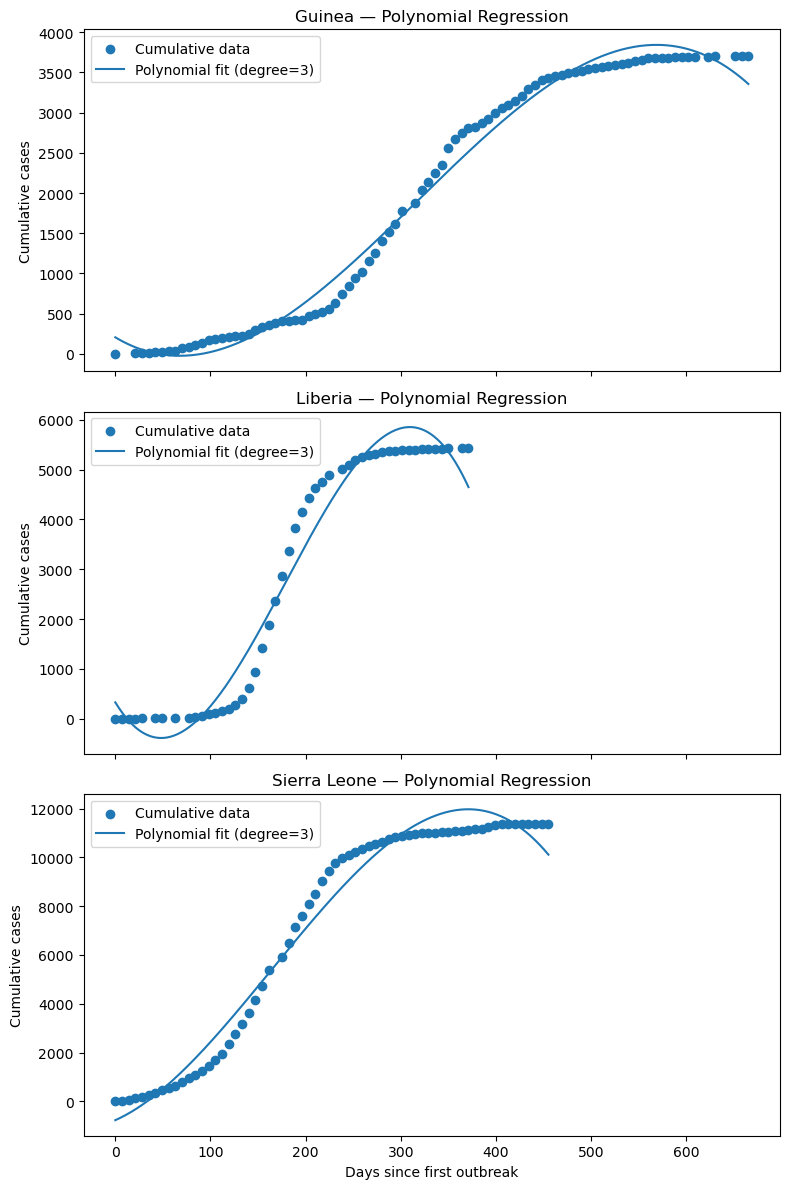

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from proj4functions import load_country

# One subplot per country
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

# Choose polynomial degree (2 or 3 are usually enough)
degree = 3
poly = PolynomialFeatures(degree=degree)

for ax, (name, path) in zip(axes, countries.items()):
    # Load data
    days, new_cases = load_country(path)
    days0 = days - days.min()
    cum_data = np.cumsum(new_cases)

    # Prepare polynomial features
    X = days0.reshape(-1, 1)
    X_poly = poly.fit_transform(X)

    # Fit linear regression 
    model = LinearRegression()
    model.fit(X_poly, cum_data)

    # Grid
    t_grid = np.linspace(days0.min(), days0.max(), 300).reshape(-1, 1)
    t_poly = poly.transform(t_grid)
    cum_pred = model.predict(t_poly)

    # Plot
    ax.scatter(days0, cum_data, label="Cumulative data")
    ax.plot(t_grid, cum_pred, label=f"Polynomial fit (degree={degree})")

    ax.set_title(f"{name} — Polynomial Regression")
    ax.set_ylabel("Cumulative cases")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Days since first outbreak")
plt.tight_layout()
plt.show()


This method is often called polynomial regression. I used scikit-learn’s PolynomialFeatures and LinearRegression to train the model for each country.

The resulting curves match the cumulative Ebola cases much more closely than the straight lines from Task 1. This shows that simple feature engineering already gives a much stronger model, even before using neural networks.

### Task 3
In this task we used a neural network to predict the cumulative Ebola cases over time for each country. The input to the model is the day index (days isnce the first outbreak), and the output is the cumulative number of cases.

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2860364.7500 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2860330.0000 
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2860300.5000 
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2860264.2500 
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2860228.7500
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2860191.7500
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2860154.2500
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2860120.5000
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2860086.7500 
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2860051.5000 
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2860018.5000 
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2859982.7500
Epoch 13/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2859948.7500
Epoch 14/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2859914.2500
Epoch

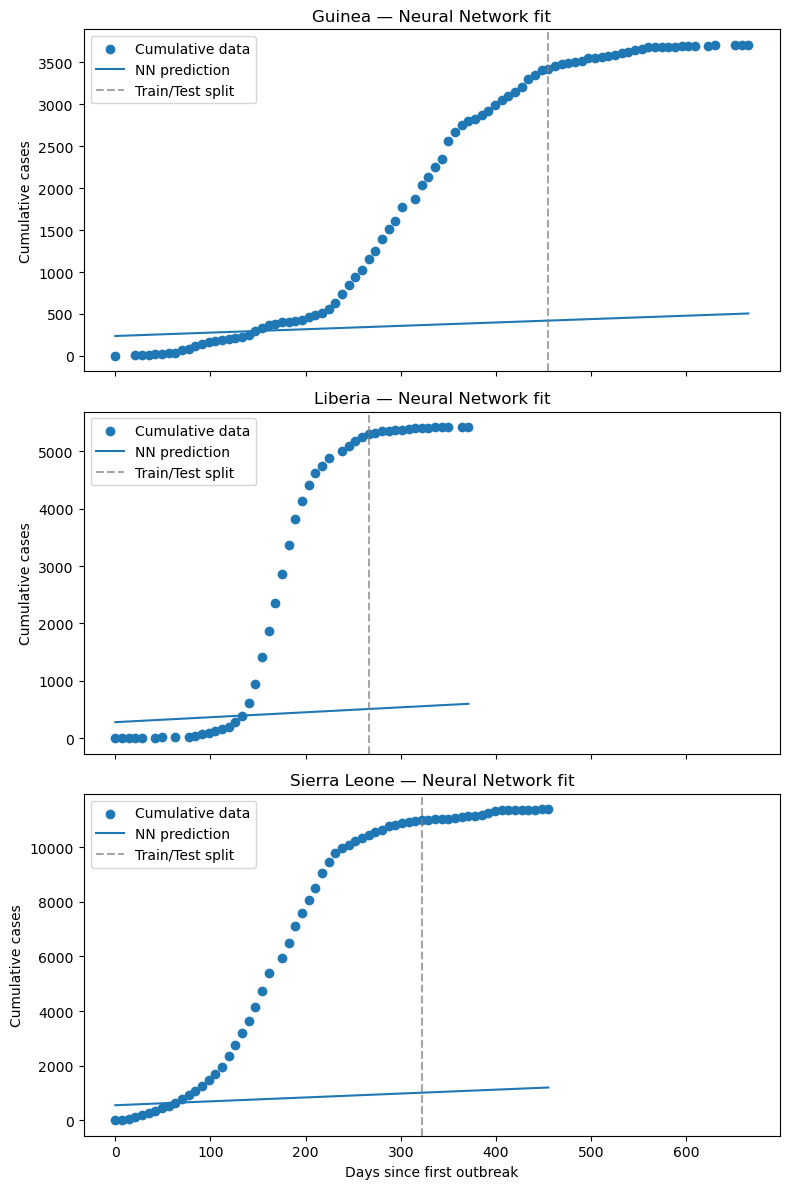

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from proj4functions import load_country

from tensorflow import keras
from tensorflow.keras import layers

fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

for ax, (name, path) in zip(axes, countries.items()):
    # Load Data-
    days, new_cases = load_country(path)
    days0 = days - days.min()
    cum_data = np.cumsum(new_cases)
    # Input X: days since first outbreak (as float)
    X = days0.astype(float).reshape(-1, 1)
    y = cum_data.astype(float)
    # normalize time to [0, 1] to help training
    t_min = X.min()
    t_max = X.max()
    X_norm = (X - t_min) / (t_max - t_min)

    #Train/test split: first 70% train, last 30% test
    n = len(X_norm)
    split_idx = int(0.7 * n)

    X_train, X_test = X_norm[:split_idx], X_norm[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    # Neural Network model
    model = keras.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)  # output: predicted cumulative cases
    ])

    model.compile(optimizer="adam", loss="mse")

    # Model training
    history = model.fit(
        X_train, y_train,
        epochs=500,
        verbose=1 #can be set to 0 if one doesn´t want to see the training
    )

    # Train/Test evaluation
    train_mse = model.evaluate(X_train, y_train, verbose=0)
    test_mse = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name}: train MSE = {train_mse:.1f}, test MSE = {test_mse:.1f}")

    # Grid
    t_grid = np.linspace(days0.min(), days0.max(), 300).reshape(-1, 1)
    t_grid_norm = (t_grid - t_min) / (t_max - t_min)
    cum_pred = model.predict(t_grid_norm, verbose=0).ravel()
    # Plotting
    ax.scatter(days0, cum_data, label="Cumulative data")
    ax.plot(t_grid.ravel(), cum_pred, label="NN prediction")
    # Mark the train/test split with a vertical line
    split_day = days0[split_idx]
    ax.axvline(split_day, color="gray", linestyle="--", alpha=0.7, label="Train/Test split")

    ax.set_title(f"{name} — Neural Network fit")
    ax.set_ylabel("Cumulative cases")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Days since first outbreak")
plt.tight_layout()
plt.show()


To respect the time ordering, hte data was split into a training set on the first 70% on days, and into a test set the last 30% of days. 

Data was not shuffled, because in a time series we are not allowed to train on the future and test on the past (also this doesn´t make sense). 

The neural network is a small feedforward model with two hidden layers and one output neuron for hte predicted cumulative cases. They were trained using the Adam optimizer and mean squared error as the loss function.

The plots show that the neural network can follow the epidemic curve more flexibly than the simple straight line from Task 1. However, the quality of the prediction on the test part depends on how well the model generalizes to future days. This is important to keep in mind, since a model that fits the training data very well can still make poor predictions for the later part of the epidemic.

### Task 4

In this task, we applied an LSTM network to the cumulative Ebola case data.
We followed the LSTM procedure described in the tutorial “Time Series Prediction with LSTM Recurrent Neural Networks in Python with Keras”

/opt/anaconda3/envs/ebola-tf/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Guinea: Train RMSE=40.8, Test RMSE=89.0


/opt/anaconda3/envs/ebola-tf/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Liberia: Train RMSE=374.0, Test RMSE=720.5


/opt/anaconda3/envs/ebola-tf/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Sierra Leone: Train RMSE=284.3, Test RMSE=215.2


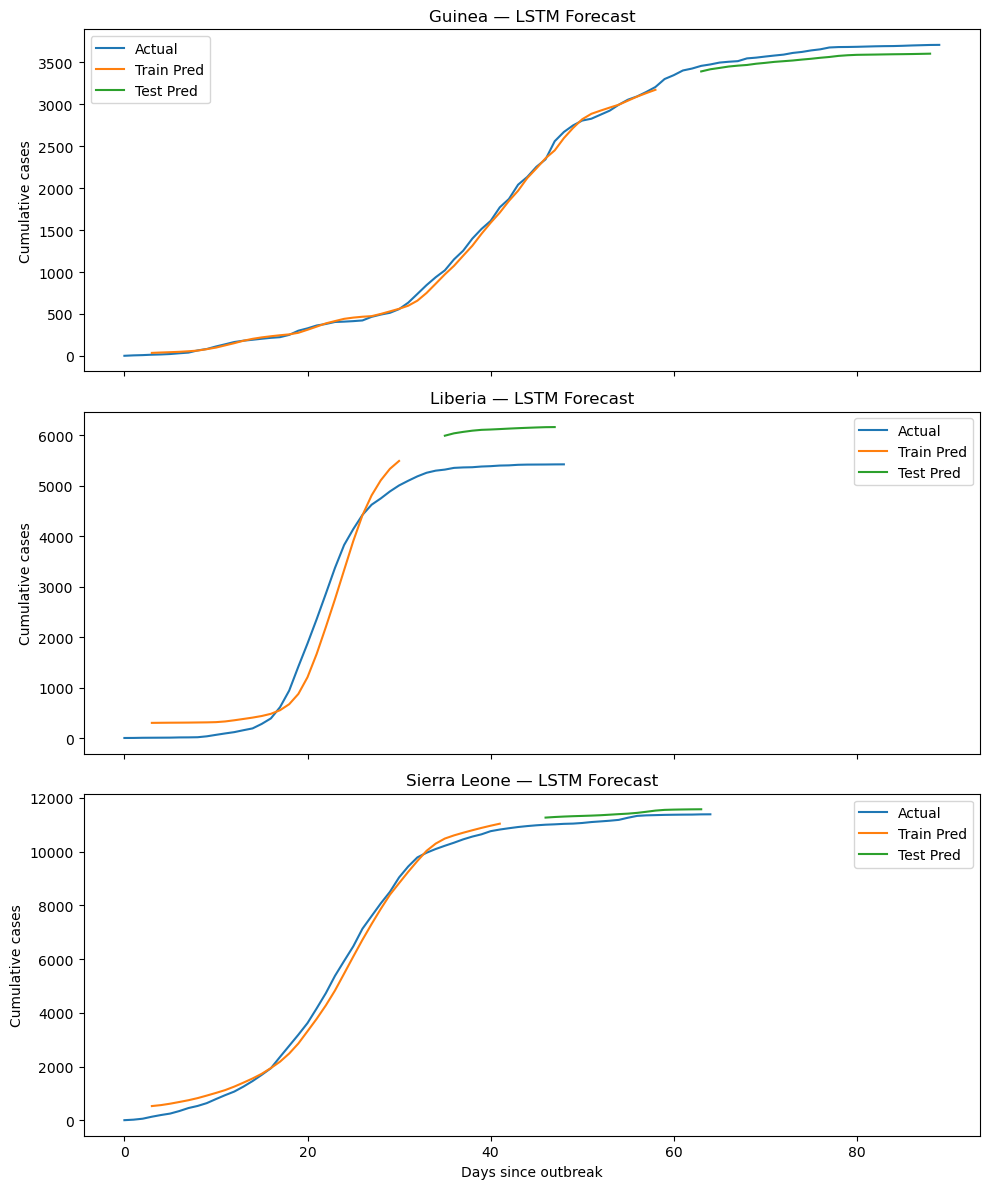

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from proj4functions import load_country, create_dataset

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error


# LSTM look-back window
look_back = 3  

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for ax, (name, path) in zip(axes, countries.items()):
    # Load old data
    days, new_cases = load_country(path)
    cum_data = np.cumsum(new_cases).reshape(-1, 1)

    # Scale data 0–1 
    scaler = MinMaxScaler(feature_range=(0, 1))
    dataset = scaler.fit_transform(cum_data)
    # Train/test split (same as tutorial: 67/33)
    train_size = int(len(dataset) * 0.67)
    train, test = dataset[:train_size], dataset[train_size:]
    # Create input/output sequences
    trainX, trainY = create_dataset(train, look_back)
    testX, testY = create_dataset(test, look_back)
    # Reshape to [samples, time steps, features]
    trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
    testX  = np.reshape(testX,  (testX.shape[0], 1, testX.shape[1]))

    # Build LSTM model 
    model = Sequential()
    model.add(LSTM(8, input_shape=(1, look_back)))  # tutorial uses 4 units; 8 works better here
    model.add(Dense(1))
    model.compile(loss="mean_squared_error", optimizer="adam")

    # Train model
    model.fit(trainX, trainY, epochs=50, batch_size=1, verbose=0)

    # Predictions 
    trainPred = model.predict(trainX)
    testPred = model.predict(testX)
    # Invert scaling
    trainPred = scaler.inverse_transform(trainPred)
    testPred  = scaler.inverse_transform(testPred)
    trainY_inv = scaler.inverse_transform([trainY])
    testY_inv  = scaler.inverse_transform([testY])

    # RMSE
    trainRMSE = np.sqrt(mean_squared_error(trainY_inv[0], trainPred[:, 0]))
    testRMSE  = np.sqrt(mean_squared_error(testY_inv[0], testPred[:, 0]))
    print(f"{name}: Train RMSE={trainRMSE:.1f}, Test RMSE={testRMSE:.1f}")

    # Plotting
    dataset_plot = scaler.inverse_transform(dataset)

    trainPlot = np.empty_like(dataset_plot)
    trainPlot[:, :] = np.nan
    trainPlot[look_back:len(trainPred) + look_back, :] = trainPred

    testPlot = np.empty_like(dataset_plot)
    testPlot[:, :] = np.nan
    testPlot[len(trainPred) + (look_back*2) + 1 : len(dataset_plot) - 1, :] = testPred

    ax.plot(dataset_plot, label="Actual")
    ax.plot(trainPlot, label="Train Pred")
    ax.plot(testPlot, label="Test Pred")

    ax.set_title(f"{name} — LSTM Forecast")
    ax.set_ylabel("Cumulative cases")
    ax.legend()

axes[-1].set_xlabel("Days since outbreak")
plt.tight_layout()
plt.show()


The main steps are:
1. Normalize the cumulative case data to the range 0-1 using MinMaxScaler
2. Split the time series chronologically into a training set (≈67%) and a test set (≈33%)
3. Create input/output sequences using a look-back window (e.g 3 previous days into next day)
4. Reshape the input to the format required by LSTM
    $$ (samples, time steps=1, features=lookback) $$
5. Train a simple LSTM model with one LSTM layer and one Dense output.
6. Predict on both train and test sets, invert scaling, compute RMSE and plot.
   
The LSTM captures the curve shape much more accurately than linear models, especially the rising epidemic phase. However, because the dataset is short and noisy, the LSTM can still overfit or give unstable long-range forecasts.

### Task 5 - Discussion

In this topic we tried four different ways to describe and predict the Ebola epidemic.

The first was the mehcanistic SEIR-like model from Project 2, which parameters like infection and recovery rate.

The second was linear and polynomial regression on cumulative cases, which showed that one can get semi-accurate results without the use of neural networking.

Then we used a feed-forward neural network.

And at last an LSTM network for time series.
1. Can we ignore modeling and just let machine learning make predictions?
   
Short answer is no. The SEIR model in Task 0 is based on how the disease actually spreads (susceptible - exposed - infectious - removed). Its parameters have a meaning; they say something about contact rate, incubation time, recovery time, etc.

The machine learning models mainly learn the shape of the curve from the data given. They do not know what "infection" or "recovery" is. They are good at interpolation but bad at answering "what if?" questions. 

For a short period, with enough data, machine learning can follow the curve quite well, especially polyniomial regression, NN and LSTM. But if we change something in the real world (lockdowns, vaccines, new variant etc.) the learned pattern may no longer be accurate.

So machine learning is a useful tool to fit and forecast, but it cannot replace mechanistic models for epidemics. 

2. What is a "good prediction" in this context?
   
For the Ebola time series, a good prediction should capture the overall shape of the cumulative cases (slow start, fast growth, then saturation). It should also be reasonable in near future (next days, weeks) not just on the training data. And it should also give information that is useful for decisions, e.g when the peak happens, how big it might be, and how roughly many cases we can expect. 

Looking at the results: 
* The simple line in Task 1 clearly fails: it cannot capture the curve at all, so its not a good prediction.
* The polynomial regression in task 2 and the NN in Task 3 firt the historical curve better, but they may overfit and can behave strangely when extrapolating far beyond the data.
* The LSTM in task 4 is able to follow the curve and use temporal structure, but it still mostly learns to imitate the observed pattern; with such a small dataset, its long-term forecasts are uncertain.

So in our opinion, a "good prediction" is a short term forecast that follows the current trend and acknowledges that long term numbers are very uncertain and depend on human actions.

3. Overall conclusions
   
* Mechanistic model
  * Pros: interpretabillity, grounded in disease dynamics.
  * Cons: needs assumptions and parameter fitting; can be wrong if the assumed structure is wrong.
* Linear/polynomial regression:
  * Linear is clearly too simple
  * Polynomial can mimic the curve, but has no understanding of the process and may misbehave outside the data range.
* Neural network
  * Flexible and can approximate the curve well.
  * Needs careful splitting, scaling and parameters. It still has limited interpretabillity. 
* LSTM:
  * Uses time series structure and can odel the curve over time
  * With short epidemic data it is easy to overfit and long term forecasts are unreliable.


  * In our LSTM results there is a small gap between the train prediction curve and the test prediction curve. This gap appears because the LSTM is trained on sliding windows of size look_back, and these windows cannot cross the boundary between the training set and the test set. When the data is split chronologically, there is a region of a few days where:
there are no valid training windows, and
there are not yet any valid test windows,
so the LSTM never produces predictions for those time steps. When the prediction arrays are plotted, these positions remain NaN, and Matplotlib simply leaves them blank. This is why the curve looks like it is “missing a piece” near the train/test split.
This is normal behavior for the sliding-window LSTM method and not an error in the code

With this, we can conclude that we cannot safely ignore modeling and just trust machine learning predictions, especially for long term policy decisions.
Machine learning is powerful for short term forecasts and for exploring patterns, but it must be combined with domain knowledge and mechanistic models.
For epidemics, a “good prediction” is realistic, short-term, and used together with an understanding of how the disease spreads, not instead of it.

## Self Reflection and Declaration of use of AI

We have used ChatGPT to help explain concepts, fix errors, graph plots, and overall troubleshooting. 

### Self reflections
#### Andy
At the end of this assignment, I found the provided helper function to be especially valuable. It served as a concise guide that clarified the expected structure of the solution and helped me understand how to approach the problem effectively.

#### Parsa
At the end of topic 2, I found the progression of models, starting from simple regression and moving toward neural networks and LSTMs, to be a learning experience. It clearly showed how different methods capture different aspects of the epidemic curve, and it helped me understand the strengths and weaknesses of data driven forecasting. Working through each task gave me a better sense of how these models behave in practice and what is required to use them effectively.



# Individuals contribution:

Andy worked on Topic 1 and Parsa worked on Topic 2. We helped each other whenever problems came up.